In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
import matplotlib.pyplot as plt
from tqdm import tqdm

In [65]:
plt.style.use(
    '../Dataset-And-Solve-Class/class-12-ML-how-machine-learns/class-12-deeplearning.mplstyle'
)

In [66]:
np.random.seed(42) #seed define
n_samples = 100 #total sample data

area = np.random.uniform(500, 3000, n_samples) #min 500, max 3000, total n_samples random num generate
price = 150 * area + 50000 + np.random.normal(0, 20000, n_samples) #price = 150 × area + 50000 + noise, here, 150 is per sqft price, 50000 is base price, noise for random variation

housing_dataset = pd.DataFrame({ #create the dataframe with n_samples (100) with area and price
    'area': area,
    'price': price
}).round(2) # two number after decimal

housing_dataset.head()

,area,price
0,1436.35,267193.49
1,2876.79,475537.72
2,2329.98,401332.94
3,1996.65,309745.55
4,890.05,179113.55


In [67]:
#min max normalization
housing_dataset = housing_dataset / housing_dataset.max() #the distribution curve for with/without normalization is same. 
housing_dataset.head()

,area,price
0,0.484073,0.523171
1,0.969524,0.931114
2,0.785240,0.785819
3,0.672903,0.606489
4,0.299961,0.350709


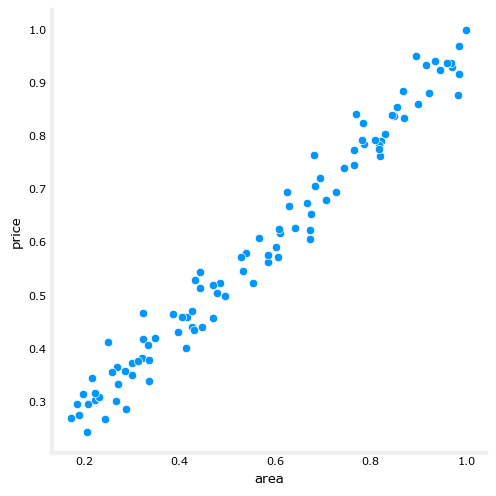

In [68]:
#relation price vs area
sns.relplot(
    data=housing_dataset,
    x='area',
    y='price'
)

In [69]:
def get_house_price(X, w, b):
    y_pred = w * X + b # w -> per sqft price, b -> registration cost, X - area
    return y_pred

In [70]:
w = np.random.uniform(0,1)
b = np.random.uniform(0,1)
print(w,b)

0.7948113035416484 0.5026370931051921


In [71]:
housing_dataset['price_pred_rand'] = get_house_price(housing_dataset['area'],w,b)
housing_dataset.head()

,area,price,price_pred_rand
0,0.484073,0.523171,0.887383
1,0.969524,0.931114,1.273225
2,0.785240,0.785819,1.126755
3,0.672903,0.606489,1.037468
4,0.299961,0.350709,0.741049


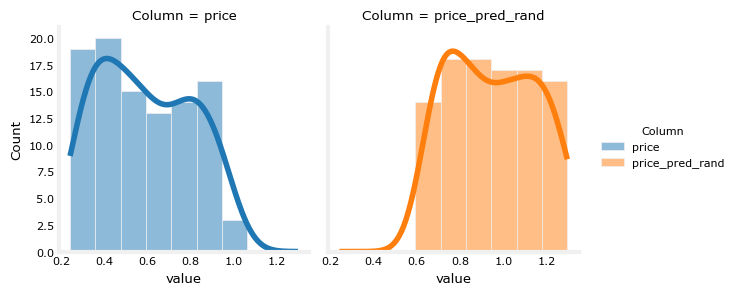

In [72]:
sns.displot(
    data=housing_dataset.melt(value_vars=['price', 'price_pred_rand'], var_name='Column'), #displot for price and price_pred_rand. we can add more
    x='value',
    col='Column',
    height=3,
    kind='hist',
    kde=True,
    hue='Column',
    palette=['#1f77b4', '#ff7f0e']
)

In [73]:
""" KL Divergence
Dissimilarities between distributions
"""

""" KL divergence: Smaller is better. 0 is best i.e. no dissimilarities
"""
import numpy as np
from scipy.stats import gaussian_kde

def kl_divergence(p_data, q_data, n_points=1000, epsilon=1e-10):
    p_data = np.array(p_data).flatten()
    q_data = np.array(q_data).flatten()
    p_data = p_data[~np.isnan(p_data)]
    q_data = q_data[~np.isnan(q_data)]
    if len(p_data) == 0 or len(q_data) == 0:
        return np.nan    
    all_data = np.concatenate([p_data, q_data])
    support = np.linspace(all_data.min(), all_data.max(), n_points)
    kde_p = gaussian_kde(p_data)
    kde_q = gaussian_kde(q_data)
    p = kde_p(support)
    q = kde_q(support)
    p = np.clip(p, epsilon, None)
    q = np.clip(q, epsilon, None)
    p /= p.sum()
    q /= q.sum()
    kl = np.sum(p * np.log(p / q))
    return kl

kl_value = kl_divergence(
    housing_dataset['price'],
    housing_dataset['price_pred_rand']
)
print(f"KL(price || price_pred_rand) = {kl_value:.4f}")

KL(price || price_pred_rand) = 2.8856


In [74]:
#calculate cost funtion MSE
def cost_function(X, y_true, w, b):
    y_pred = get_house_price(x, w, b)
    mse = np.sum((y_true - y_pred) ** 2) / len(y_true)
    return mse

In [75]:
X = housing_dataset['area']
y_true = housing_dataset['price']

loss = cost_function(x, y_true, w, b)
print(loss)

0.13209874399184798


In [76]:
loss_1 = cost_function(X, y_true, w=100, b=125)
print(loss_1)

loss_2 = cost_function(X, y_true, w=124, b=189)
print(loss_2)

loss_3 = cost_function(X, y_true, w=112, b=169)
print(loss_3)

33327.34790611617
67727.82855692986
54430.6965973278


In [77]:
#calculate loss for 10K point (w,b) and draw the shape
""" ML model's objective is to reduce loss / cost function.
"""
weights = np.linspace(-10, 10, 100)
biases = np.linspace(-10, 10, 100)
weights_mesh, biases_mesh = np.meshgrid(weights, biases)

""" We will produce 100,00 points
Each point: (w, b, loss)
"""
losses_mesh = []
for w in tqdm(np.ravel(weights_mesh[0])):
    for b in np.ravel(biases_mesh[0]):
        loss = cost_function(X, y_true, w, b)        
        losses_mesh.append(loss)
        
losses_mesh = np.array(losses_mesh)
losses_mesh = losses_mesh.reshape(weights_mesh.shape)

100%|██████████| 100/100 [00:01<00:00, 84.73it/s]


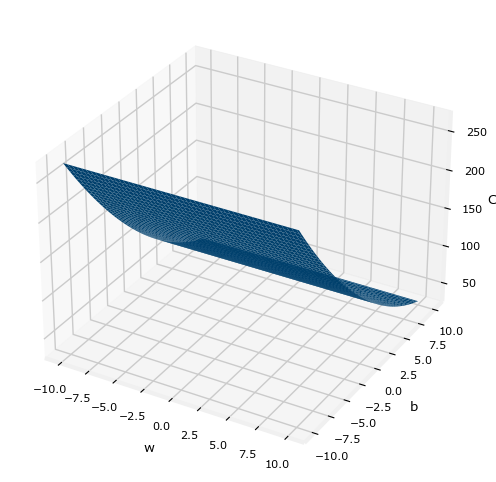

In [78]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(weights_mesh, biases_mesh, losses_mesh)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost')
plt.show()

In [79]:
""" Gradient Descent - ultimate goal is to reach the minimum w,b for minimize cost and maximize the prediction accuracy
"""
def compute_gradient(X, y_true, w, b):
    delta=0.001 #very small number
    cost1 = cost_function(X, y_true, w, b) #original cost, may be not good, so, we need to minimize cost for best prediction
    cost2 = cost_function(X, y_true, w + delta, b) #change small portion of w [weights]
    cost3 = cost_function(X, y_true, w, b + delta) #change small portion of b [bias]
    dw = (cost2 - cost1) / delta
    db = (cost3 - cost1) / delta #result
    return dw, db

In [80]:
w = np.random.uniform(0, 1)
b = np.random.uniform(0, 1)

In [81]:
loss = cost_function(X, y_true, w, b)
print(loss)

0.05801109339975867


In [82]:
dw, db = compute_gradient(X, y_true, w, b)
print(dw, db)

0.22424383541521514 0.4576472465522702


In [83]:
""" Weight update 
If dw = -0.25 then w = w - (-0.25) = w + 0.25 
If dw = 0.25 then w = w - 0.25 = w - 0.25
"""
learning_rate = 0.01
w = w - learning_rate * dw
b = b - learning_rate * db

print(w,b)

0.5746614462722069 0.48794122135334117


In [84]:
#calculate loss using updated w,b
"""lr=0.01, loss=0.58, next loss=0.55, change=0.03
   lr=0.0001, loss=0.086838, next loss=0.086810, change=0.00028
   lr=1.5, loss=0.187, next loss=1.59, negative change
"""
print(f'previous loss = {loss}')
loss = cost_function(X, y_true, w,b)
print(f'current loss = {loss}')

previous loss = 0.05801109339975867
current loss = 0.05545371089508798


In [85]:
for epoch in range(1000):
    # Calculate logits
    loss = cost_function(X, y_true, w, b)
    # Calculate the gradients
    dw, db = compute_gradient(X, y_true, w, b)
    
    # Update weights
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if epoch % 100 == 0:
        print(loss)

0.05545371089508798
0.008561969890145132
0.007150751885868859
0.00613915818595061
0.0053002967336879805
0.004604565115411596
0.004027605830485799
0.0035491765443006872
0.0031524800236088684
0.0028235798906703913


In [86]:
print(w,b)

0.705455664304135 0.19514075278160728


In [87]:
housing_dataset["price_pred_learned"] = get_house_price(housing_dataset["area"], w, b) #new price predict using optimam w,b
housing_dataset.head()

,area,price,price_pred_rand,price_pred_learned
0,0.484073,0.523171,0.887383,0.536633
1,0.969524,0.931114,1.273225,0.879097
2,0.785240,0.785819,1.126755,0.749093
3,0.672903,0.606489,1.037468,0.669844
4,0.299961,0.350709,0.741049,0.406750


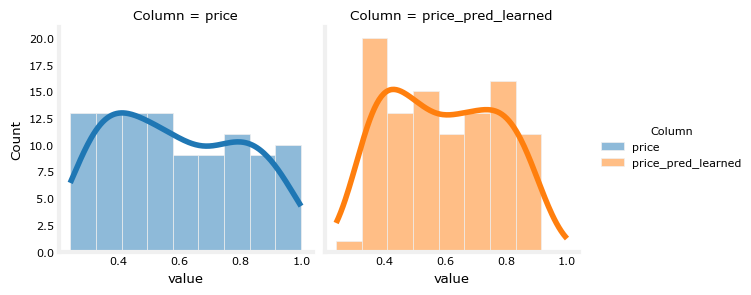

In [88]:
sns.displot(
    data=housing_dataset.melt(value_vars=['price', 'price_pred_learned'], var_name='Column'),
    x='value',
    col='Column',
    kind='hist',
    height=3,
    kde=True,
    hue='Column',
    palette=['#1f77b4', '#ff7f0e']
)

In [ ]:
#check KL Divergence - Dissimilarity
kl_value_before = kl_divergence(housing_dataset['price'], housing_dataset['price_pred_rand']) #with random w,b
kl_value_after = kl_divergence(housing_dataset['price'], housing_dataset['price_pred_learned']) #with optimized w,b

print(kl_value_before)
print(kl_value_after)

2.885565659438694
0.035759770908260685
